## Dependencias
# Ejecutar este comando para instalar las librerías necesarias
```
penv/Scripts/activate
pip install pandas numpy scikit-learn matplotlib seaborn jinja2
```

In [5]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder # Librería para crear modelos de ML

In [6]:
df_inicial = pd.read_csv("/content/bmw_pricing_v3.csv")

In [7]:
print("Shape:", df_inicial.shape)
df_inicial.head()

Shape: (4843, 18)


,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


In [8]:
df_inicial.isnull().sum()

,0
marca,970
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486


In [9]:
df_inicial.isnull().any()

,0
marca,True
modelo,True
km,True
potencia,True
fecha_registro,True
tipo_gasolina,True
color,True
tipo_coche,True
volante_regulable,True
aire_acondicionado,True


In [10]:
df_inicial.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [11]:
# Conversión con pd.to_datetime de los atributos que tienen fecha y son float
df_inicial_test = df_inicial.copy()
for i in df_inicial.columns:
    if str(i).upper().startswith('FECHA'):
        df_inicial_test[i] = pd.to_datetime(df_inicial[i])

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   marca                        3873 non-null   object        
 1   modelo                       4840 non-null   object        
 2   km                           4841 non-null   float64       
 3   potencia                     4842 non-null   float64       
 4   fecha_registro               2420 non-null   datetime64[ns]
 5   tipo_gasolina                4838 non-null   object        
 6   color                        4398 non-null   object        
 7   tipo_coche                   3383 non-null   object        
 8   volante_regulable            4839 non-null   object        
 9   aire_acondicionado           4357 non-null   object        
 10  camara_trasera               4841 non-null   object        
 11  asientos_traseros_plegables  1452 non-null 

In [12]:
df_inicial_test[df_inicial_test.duplicated(keep='first')].shape

(0, 18)

No hay duplicados

In [13]:
# Porcentaje de nulos
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.0f}% \tde nulos en {i}')

20% 	de nulos en marca
0% 	de nulos en modelo
0% 	de nulos en km
0% 	de nulos en potencia
50% 	de nulos en fecha_registro
0% 	de nulos en tipo_gasolina
9% 	de nulos en color
30% 	de nulos en tipo_coche
0% 	de nulos en volante_regulable
10% 	de nulos en aire_acondicionado
0% 	de nulos en camara_trasera
70% 	de nulos en asientos_traseros_plegables
0% 	de nulos en elevalunas_electrico
15% 	de nulos en bluetooth
0% 	de nulos en gps
15% 	de nulos en alerta_lim_velocidad
0% 	de nulos en precio
0% 	de nulos en fecha_venta


In [14]:
# No es correcto, en todos los atributos hay nulos salvo en GPS, saca los decimales del procentaje
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.2f}% \tde nulos en {i}')

20.03% 	de nulos en marca
0.06% 	de nulos en modelo
0.04% 	de nulos en km
0.02% 	de nulos en potencia
50.03% 	de nulos en fecha_registro
0.10% 	de nulos en tipo_gasolina
9.19% 	de nulos en color
30.15% 	de nulos en tipo_coche
0.08% 	de nulos en volante_regulable
10.04% 	de nulos en aire_acondicionado
0.04% 	de nulos en camara_trasera
70.02% 	de nulos en asientos_traseros_plegables
0.04% 	de nulos en elevalunas_electrico
15.03% 	de nulos en bluetooth
0.00% 	de nulos en gps
15.03% 	de nulos en alerta_lim_velocidad
0.12% 	de nulos en precio
0.02% 	de nulos en fecha_venta


In [15]:
df_inicial_test["marca"].value_counts(dropna=False)

,count
marca,
BMW,3873
NaN,970


Borramos la columna marca debido a que es irrelevante al tratarse todo de BMW

In [16]:
df_inicial_test.drop(columns=['marca'], inplace=True)

In [17]:
df_inicial_test["precio"].describe()

,precio
count,4837.000000
mean,15831.920612
std,9222.630708
min,100.000000
25%,10800.000000
50%,14200.000000
75%,18600.000000
max,178500.000000


Text(0, 0.5, 'Frecuencia')

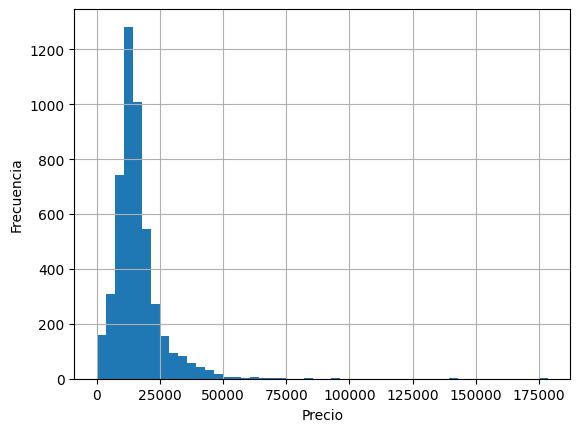

In [18]:
df_inicial_test.precio.hist(bins=50)
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

In [41]:
def columnas_por_tipo(df, as_dict=False):
    """
    Agrupa las columnas de un DataFrame por tipo y devuelve las listas de nombres de columnas.

    Parámetros:
    - df: pandas.DataFrame
    - as_dict: bool (opcional). Si True devuelve un dict con las listas;
               si False (por defecto) devuelve una tupla con las listas en el
               siguiente orden: (numeric, bools, datetimes, objects, categories,
               timedeltas, complex_cols, ints, floats, others).

    Retorno:
    - Si as_dict=True: dict con claves 'all','numeric','int','float','bool',
      'datetime','object','category','timedelta','complex','others'.
    - Si as_dict=False: tupla de listas: (numeric, bools, datetimes, objects,
      categories, timedeltas, complex_cols, ints, floats, others).

    Ejemplos:
    - numeric, bools, datetimes, objects, categories, timedeltas, complex_cols,
      ints, floats, others = columnas_por_tipo(df)
    - grouped = columnas_por_tipo(df, as_dict=True)
    - df[numeric].head()  # muestra solo columnas numéricas si 'numeric' es la lista
    """
    # columnas por tipos básicos
    numeric = df.select_dtypes(include=['number']).columns.tolist()
    bools = df.select_dtypes(include=['bool']).columns.tolist()
    datetimes = df.select_dtypes(include=['datetime']).columns.tolist()
    objects = df.select_dtypes(include=['object']).columns.tolist()
    categories = df.select_dtypes(include=['category']).columns.tolist()
    timedeltas = df.select_dtypes(include=['timedelta']).columns.tolist()
    complex_cols = df.select_dtypes(include=['complex']).columns.tolist()

    # distinguir int / float dentro de numeric
    ints = [c for c in numeric if pd.api.types.is_integer_dtype(df[c])]
    floats = [c for c in numeric if pd.api.types.is_float_dtype(df[c])]

    grouped = {
        'all': df.columns.tolist(),
        'numeric': numeric,
        'int': ints,
        'float': floats,
        'bool': bools,
        'datetime': datetimes,
        'object': objects,
        'category': categories,
        'timedelta': timedeltas,
        'complex': complex_cols,
    }

    # columnas que no encajan en los grupos anteriores
    grouped_lists = [grouped[k] for k in ['numeric','int','float','bool','datetime','object','category','timedelta','complex']]
    used = set().union(*map(set, grouped_lists)) if grouped_lists else set()
    grouped['others'] = [c for c in df.columns if c not in used]

    if as_dict:
        return grouped

    # devolver las listas en un orden fijo para permitir unpacking directo
    return (numeric, bools, datetimes, objects, categories, timedeltas,
            complex_cols, ints, floats, grouped['others'])

In [42]:
grouped_columns = columnas_por_tipo(df_inicial_test, as_dict=True)
for tipo, columnas in grouped_columns.items():
    print(f"{tipo}: {columnas}")

all: ['modelo', 'km', 'potencia', 'fecha_registro', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad', 'precio', 'fecha_venta', 'anio_registro']
numeric: ['km', 'potencia', 'precio', 'anio_registro']
int: []
float: ['km', 'potencia', 'precio', 'anio_registro']
bool: ['gps']
datetime: ['fecha_registro', 'fecha_venta']
object: ['modelo', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'alerta_lim_velocidad']
category: []
timedelta: []
complex: []
others: []


In [21]:
numeric, bools, datetimes, objects, categories, timedeltas, complex_cols, ints, floats, others = columnas_por_tipo(df_inicial_test)
df_inicial_test[numeric].head()

,km,potencia,precio
0,140411.0,100.0,11300.0
1,13929.0,317.0,69700.0
2,183297.0,120.0,10200.0
3,128035.0,135.0,25100.0
4,97097.0,160.0,33400.0


## PREGUNTA 1

In [22]:
## 1. ¿Qué columnas eliminaron inicialmente del dataset y por qué?

In [23]:
## Kike Se elimino la columna MARCA al ser todo el data set de la marca BMW

In [24]:
## Kike defino target. TARGET = "precio"

## PREGUNTA 2

In [25]:
## 2. Manejo de nulos, explicar qué se hizo con los nulos por cada columna

In [26]:
# Kike Porcentaje de nulos
for i in df_inicial_test.columns:
    prctj = df_inicial_test[i].isnull().mean() * 100
    print(f'{prctj:.2f}% \tde nulos en {i}')

0.06% 	de nulos en modelo
0.04% 	de nulos en km
0.02% 	de nulos en potencia
50.03% 	de nulos en fecha_registro
0.10% 	de nulos en tipo_gasolina
9.19% 	de nulos en color
30.15% 	de nulos en tipo_coche
0.08% 	de nulos en volante_regulable
10.04% 	de nulos en aire_acondicionado
0.04% 	de nulos en camara_trasera
70.02% 	de nulos en asientos_traseros_plegables
0.04% 	de nulos en elevalunas_electrico
15.03% 	de nulos en bluetooth
0.00% 	de nulos en gps
15.03% 	de nulos en alerta_lim_velocidad
0.12% 	de nulos en precio
0.02% 	de nulos en fecha_venta


/tmp/ipython-input-2873952471.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="anio_registro", y="precio", data=df_inicial_test, palette="Wistia")


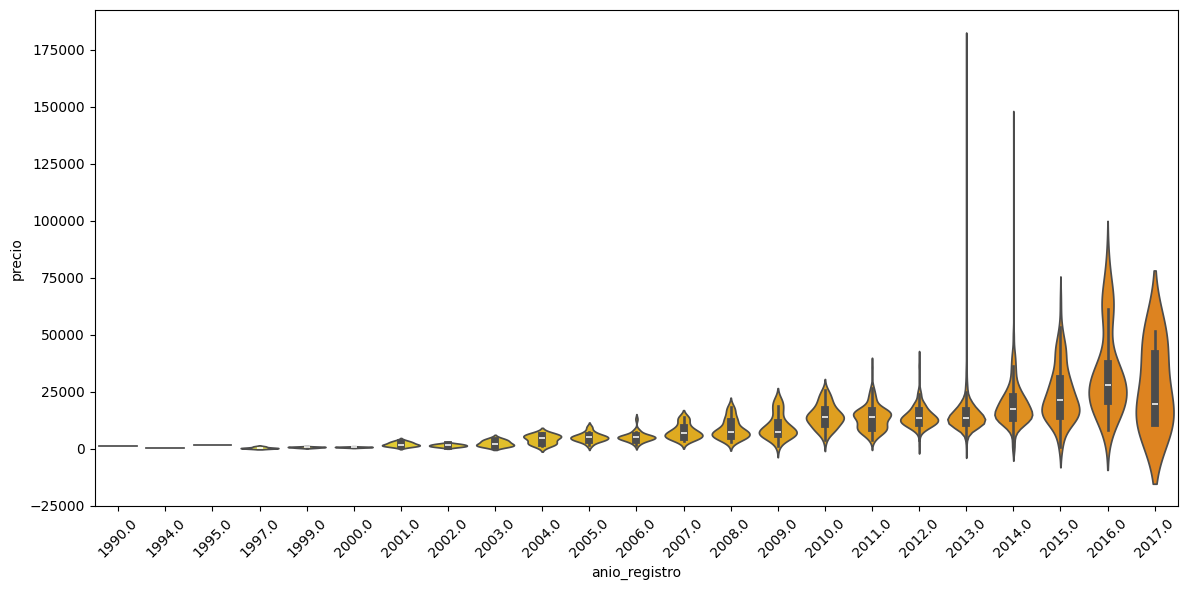

In [27]:
## Kike Vemos si fecha de registro incide en target
## Kike Este código es para transformar en años
df_inicial_test["fecha_registro"] = pd.to_datetime(
    df_inicial_test["fecha_registro"], errors='coerce'
)

df_inicial_test["anio_registro"] = df_inicial_test["fecha_registro"].dt.year


plt.figure(figsize=(12,6))
sns.violinplot(x="anio_registro", y="precio", data=df_inicial_test, palette="Wistia")
plt.xticks(rotation=45)
plt.tight_layout()


In [28]:
## Kike Esta es la propuesta:
## 20.03% 	de nulos en marca. Eliminar variable
## 0.06% 	de nulos en modelo
## 0.04% 	de nulos en km
## 0.02% 	de nulos en potencia
## 50.03% 	de nulos en fecha_registro
## 0.10% 	de nulos en tipo_gasolina
## 9.19% 	de nulos en color
## 30.15% 	de nulos en tipo_coche
## 0.08% 	de nulos en volante_regulable
## 10.04% 	de nulos en aire_acondicionado
## 0.04% 	de nulos en camara_trasera
## 70.02% 	de nulos en asientos_traseros_plegables
## 0.04% 	de nulos en elevalunas_electrico
## 15.03% 	de nulos en bluetooth
## 0.00% 	de nulos en gps
## 15.03% 	de nulos en alerta_lim_velocidad
## 0.12% 	de nulos en precio
## 0.02% 	de nulos en fecha_venta
##Kike
## Marca, eliminar variable. Son todos BMW
## Fecha registro, muchos nulos, incide en target. Pondría 0 si conozco antigüedad y 1 : no la conozco
## Asientos traseros plegables, muchos nulos, poner que no tiene. bool:0
## Entre 10%-50%, objetc:"desconocido", bool:0
## <1%. No afectan modelo. objet: "desconocido", float:mediana, bool:0
## Target precio. No se imputan, se eliminan filas

## PREGUNTA 3

In [29]:
## 3. Análisis univariable, explicar alguna información interesante encontrada

In [30]:
df_inicial_test.info()
## Kike
# No hay duplicados
# Se cambia a dates los atributos de fechas.
# Los nulos se contestaron en pregunta anterior.
# Outliers en precio (haría LOG), en potencia y km. Ver más abajo y habría que decidir qué hacer con ellos.
## Hay km negativos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [31]:
df_inicial_test.describe(include = ['object']).T

,count,unique,top,freq
modelo,4840,76,320,752
tipo_gasolina,4838,5,diesel,4631
color,4398,10,black,1499
tipo_coche,3383,8,estate,1107
volante_regulable,4839,2,True,2662
aire_acondicionado,4357,2,True,3465
camara_trasera,4841,2,False,3864
asientos_traseros_plegables,1452,2,False,1150
elevalunas_electrico,4841,2,False,2612
bluetooth,4115,2,False,3119


In [32]:
df_inicial_test.describe(exclude = ['object']).T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
km,4841.0,NaN,NaN,NaN,140959.347862,-64.0,102884.0,141080.0,175217.0,1000376.0,60208.534313
potencia,4842.0,NaN,NaN,NaN,128.981826,0.0,100.0,120.0,135.0,423.0,38.994839
fecha_registro,2420,NaN,NaN,NaN,2012-12-06 07:35:12.396694016,1990-03-01 00:00:00,2012-07-01 00:00:00,2013-07-01 00:00:00,2014-04-01 00:00:00,2017-11-01 00:00:00,NaN
gps,4843,2,True,4514,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precio,4837.0,NaN,NaN,NaN,15831.920612,100.0,10800.0,14200.0,18600.0,178500.0,9222.630708
fecha_venta,4842,NaN,NaN,NaN,2018-04-26 11:45:07.806691584,2007-08-01 00:00:00,2018-03-01 00:00:00,2018-05-01 00:00:00,2018-07-01 00:00:00,2018-09-01 00:00:00,NaN
anio_registro,2420.0,NaN,NaN,NaN,2012.507438,1990.0,2012.0,2013.0,2014.0,2017.0,2.497362


Text(0, 0.5, 'Frecuencia')

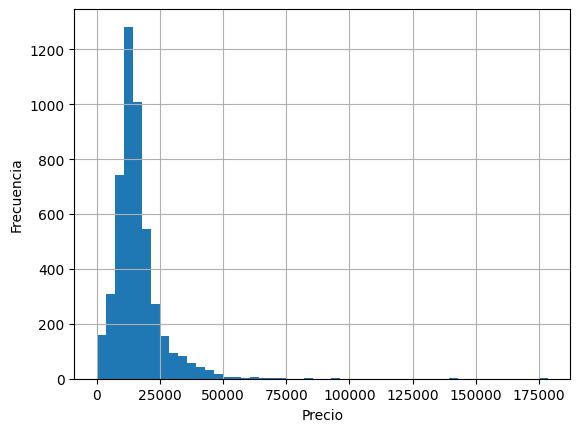

In [33]:
## Kike El precio tiene 2 outliers. Quizás sea necesario un LOG

df_inicial_test.precio.hist(bins=50)
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

<Axes: xlabel='precio'>

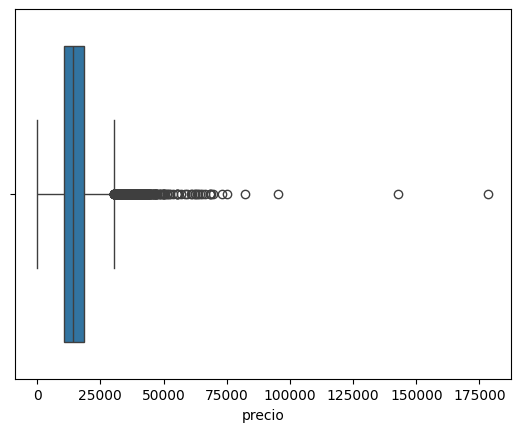

In [34]:
sns.boxplot(x=df_inicial_test["precio"])

<Axes: xlabel='km'>

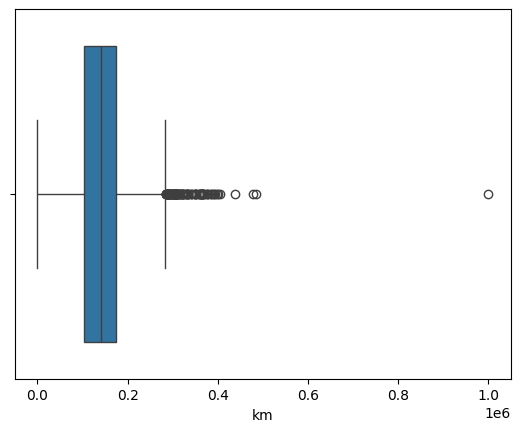

In [35]:
## Kike Miro outliers en km y potencia según describe. Hay un outlier en km y dos en potencia

sns.boxplot(x=df_inicial_test["km"])


<Axes: xlabel='potencia'>

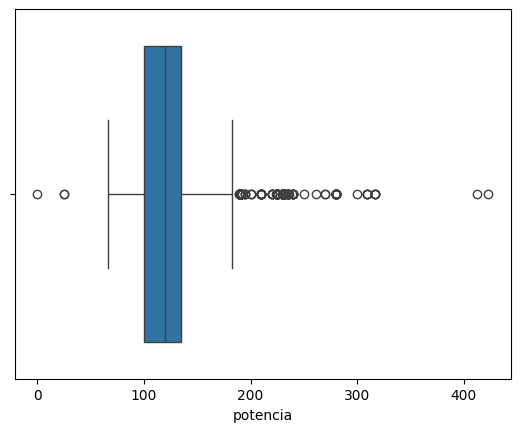

In [36]:
sns.boxplot(x=df_inicial_test["potencia"])

## PREGUNTA 4

In [37]:
## 4. Análisis de correlación inicial, ¿Hay alguna variable correlacionada?

In [38]:
## Kike Miramos correlaciones entre variables numericas. Nada a destacar, precio y km son casi opuestas
## Kike Habría que pasar las categóricas a numéricas, pero lo pide en la pregunta 6.

corr=df_inicial_test.corr(numeric_only=True)
corr.style.background_gradient(cmap='coolwarm')

,km,potencia,gps,precio,anio_registro
km,1.000000,-0.050141,0.154815,-0.410189,-0.483464
potencia,-0.050141,1.000000,0.008862,0.639254,0.092517
gps,0.154815,0.008862,1.000000,-0.005227,-0.077771
precio,-0.410189,0.639254,-0.005227,1.000000,0.427901
anio_registro,-0.483464,0.092517,-0.077771,0.427901,1.000000


## PREGUNTA 5

In [39]:
## 5. Análisis variable vs target, ¿Hay algún insight interesante?

In [40]:
df_inicial_test.info()
## Kike annio está en float, debe pasarse a datetime64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [49]:
## Kike Paso annio_registro a datetime
df_inicial_test["anio_registro"] = pd.to_datetime(df_inicial_test["anio_registro"])

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [44]:
df_inicial_test["modelo"].unique()

array(['118', 'M4', '320', '420', '425', '335', '325', 'Z4', '120', '220',
       '650', '135', '218', '318', '430', 'M3', '330', '225', 'M235',
       '316', '435', '640', '640 Gran Coupé', '435 Gran Coupé', 'i8',
       '630', '430 Gran Coupé', '635', '520', nan, '525', '530', '535',
       '320 Gran Turismo', '518', '116', '328', '523', 'X3', 'M550',
       '528', '325 Gran Turismo', '125', '318 Gran Turismo',
       '420 Gran Coupé', 'i3', '114', '520 Gran Turismo',
       '530 Gran Turismo', 'M135', '418 Gran Coupé', '330 Gran Turismo',
       '335 Gran Turismo', '730', '123', '535 Gran Turismo', '740', '750',
       'ActiveHybrid 5', '735', 'M5', 'X5', 'X1', 'X4', 'X6', 'X6 M',
       'X5 M', 'X5 M50', '218 Active Tourer', '218 Gran Tourer', '216',
       '220 Active Tourer', '216 Gran Tourer', '216 Active Tourer',
       ' Active Tourer', '225 Active Tourer', '214 Gran Tourer'],
      dtype=object)

In [50]:
## Kike listo toda las variables con sus valores únicos
for i in df_inicial_test:
  print(i,"\n\n",df_inicial_test[i].value_counts(),"\n\n")

modelo 

 modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 76, dtype: int64 


km 

 km
129317.0    2
129214.0    2
193202.0    2
72760.0     2
188713.0    2
           ..
193231.0    1
84058.0     1
303225.0    1
205603.0    1
87542.0     1
Name: count, Length: 4784, dtype: int64 


potencia 

 potencia
135.0    882
120.0    785
85.0     631
100.0    570
105.0    451
        ... 
412.0      1
0.0        1
423.0      1
300.0      1
261.0      1
Name: count, Length: 61, dtype: int64 


fecha_registro 

 fecha_registro
2013-07-01    93
2014-03-01    83
2014-05-01    81
2013-01-01    78
2013-10-01    77
              ..
2004-11-01     1
2009-12-01     1
2005-02-01     1
2004-06-01     1
2005-09-01     1
Name: count, Length: 180, dtype: int

In [51]:
## Kike Defino target
target = ["precio"]

In [73]:
## Kike Paso variable gps booleana a int
df_inicial_test["gps_bool"] = df_inicial_test["gps"].astype(int)
df_inicial_test.drop(columns=["gps"], inplace=True)
df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

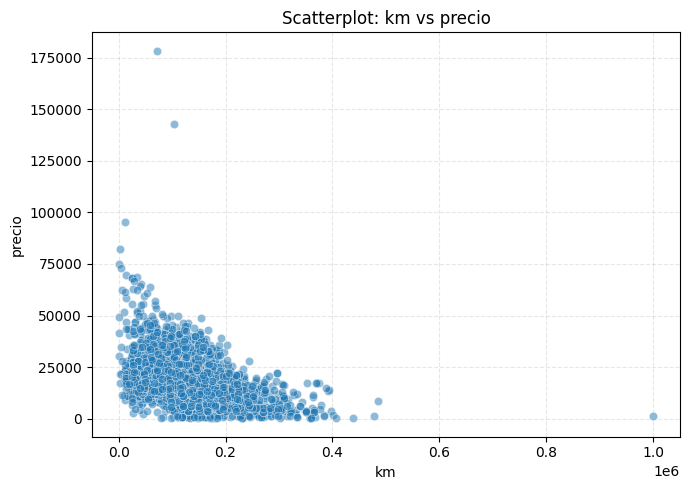

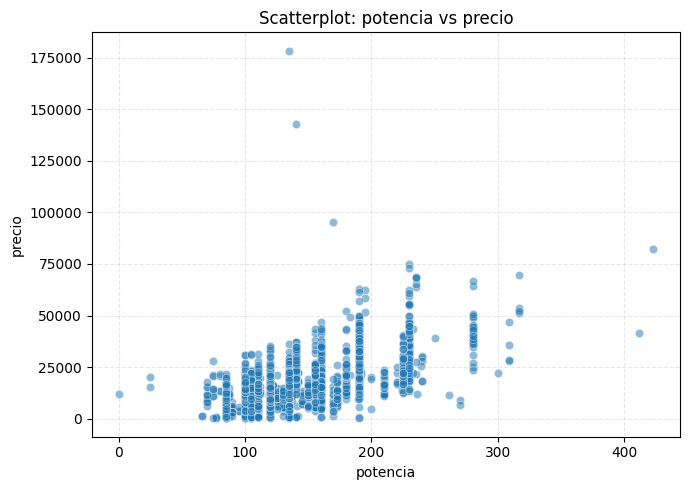

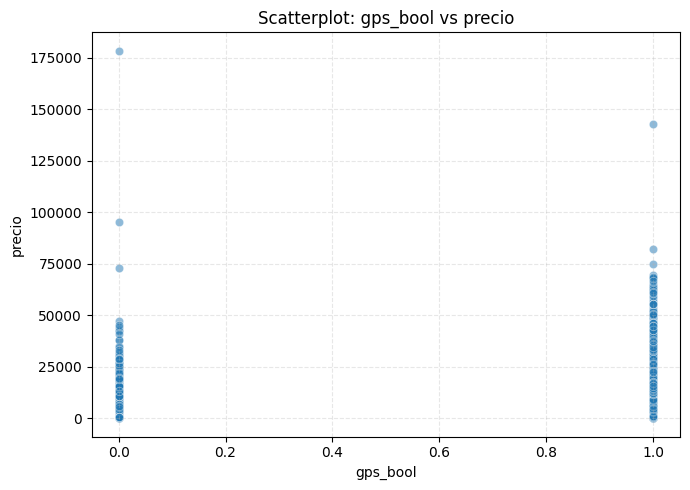

In [57]:
## Kike Variables numericas con target con scatterplot
## Kike Conclusion: a más km, menos precio y a más potencia, más precio. Con gps son más caros.
## Kike Seleccionar columnas numéricas

num_cols = df_inicial_test.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    if col == "precio":   # evitar comparar el target consigo mismo
        continue

    plt.figure(figsize=(7,5))
    sns.scatterplot(x=df_inicial_test[col], y=df_inicial_test["precio"], alpha=0.5)
    plt.title(f"Scatterplot: {col} vs precio")
    plt.xlabel(col)
    plt.ylabel("precio")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


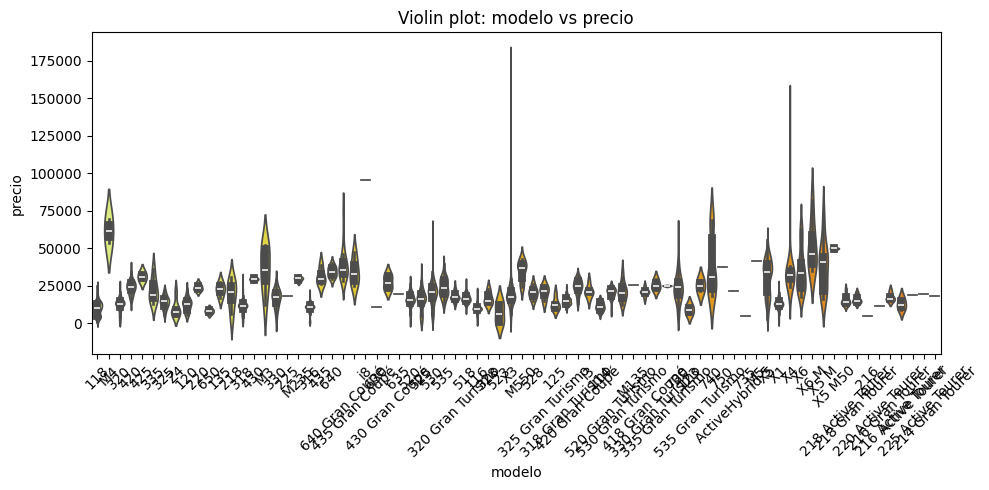

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


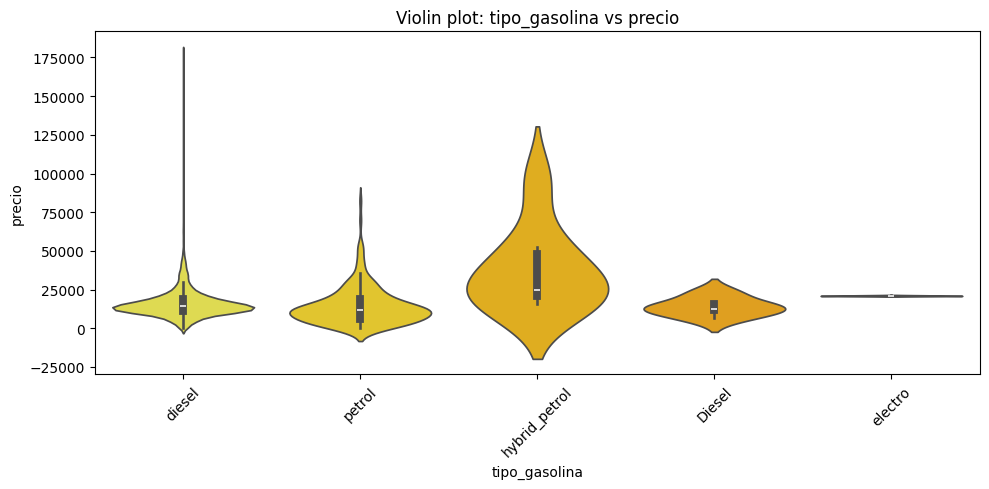

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


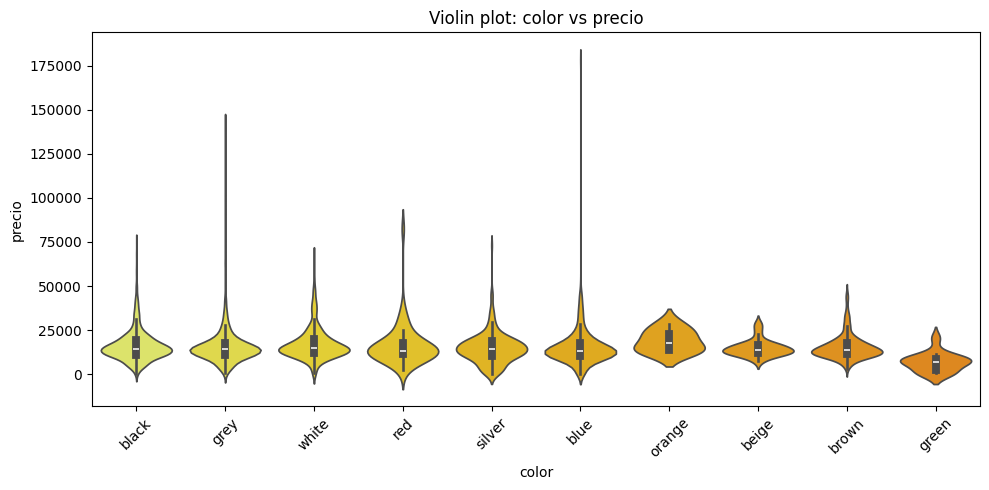

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


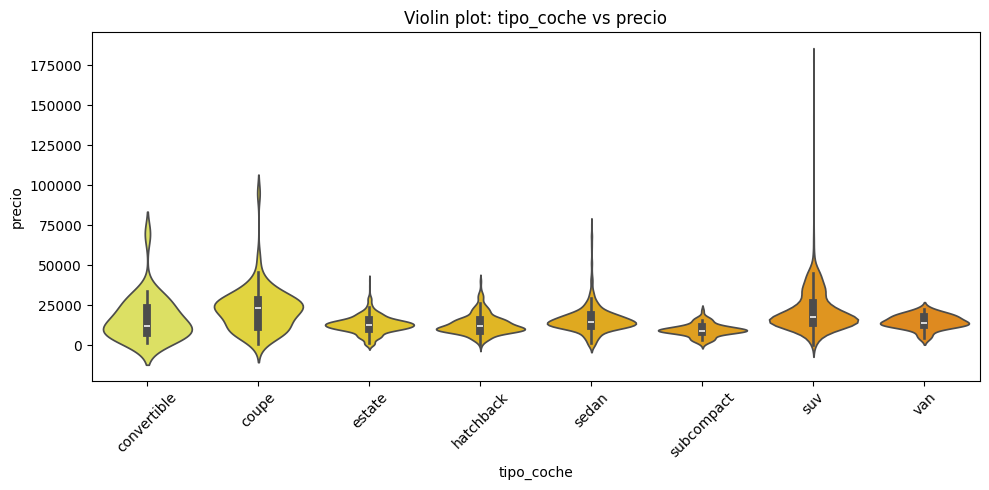

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


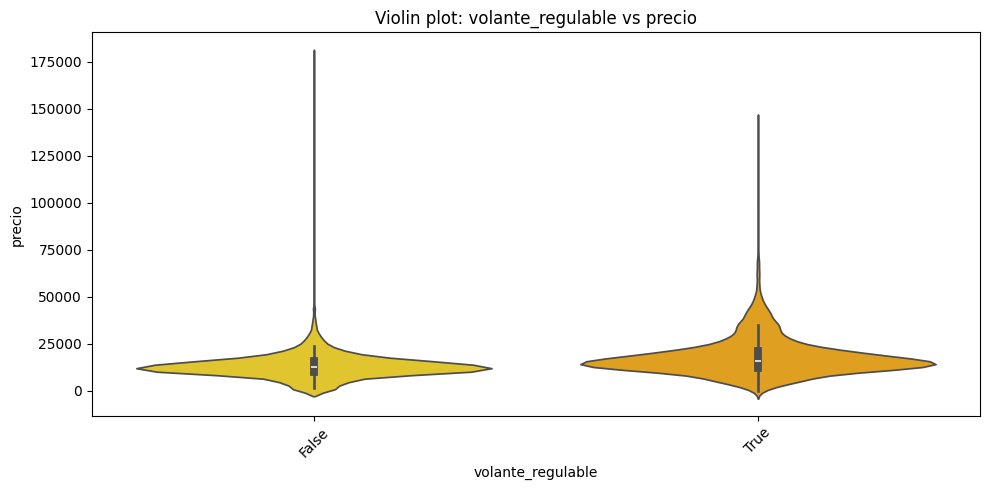

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


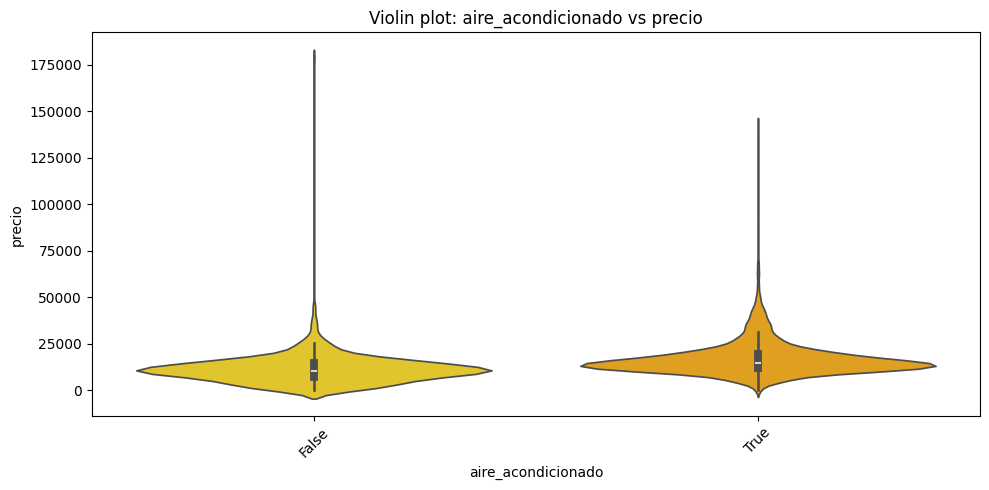

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


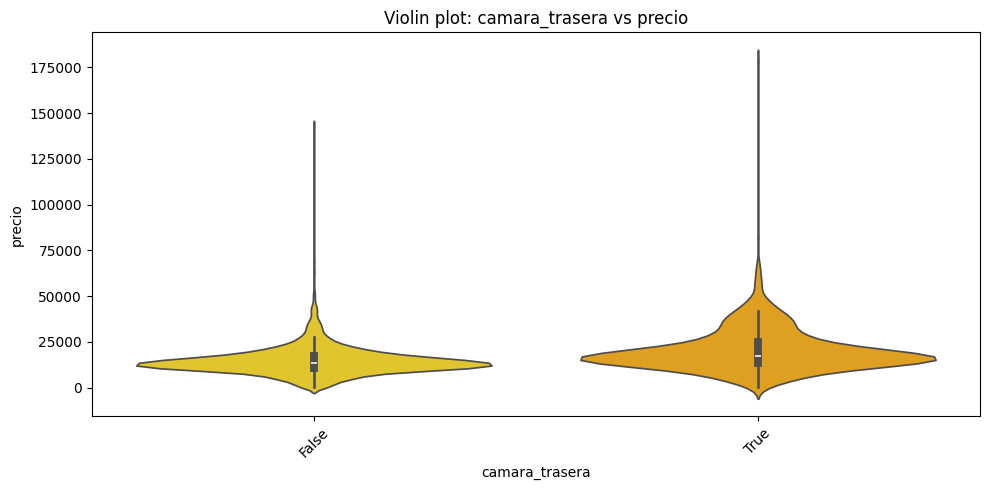

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


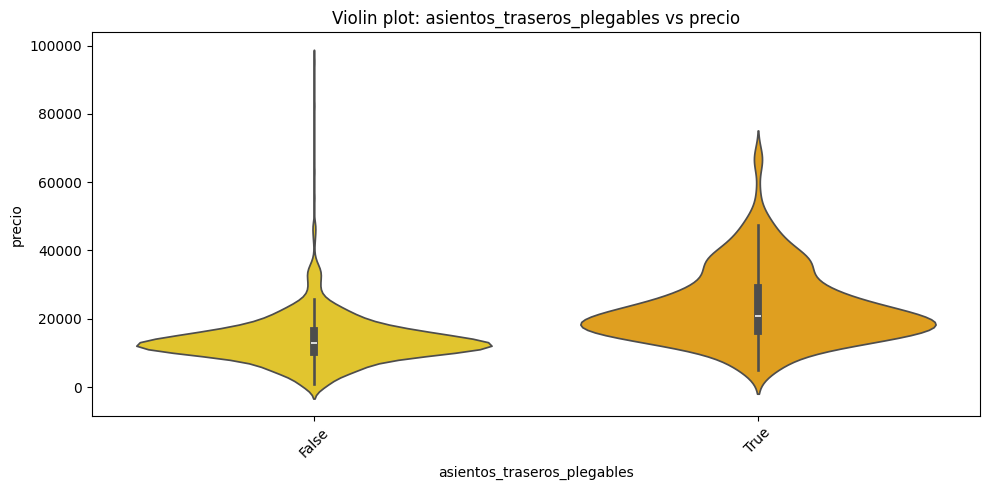

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


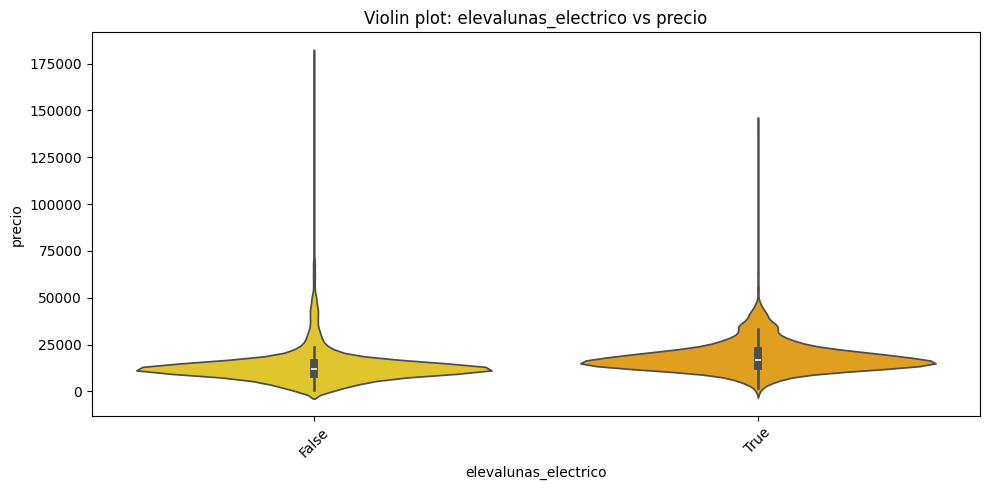

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


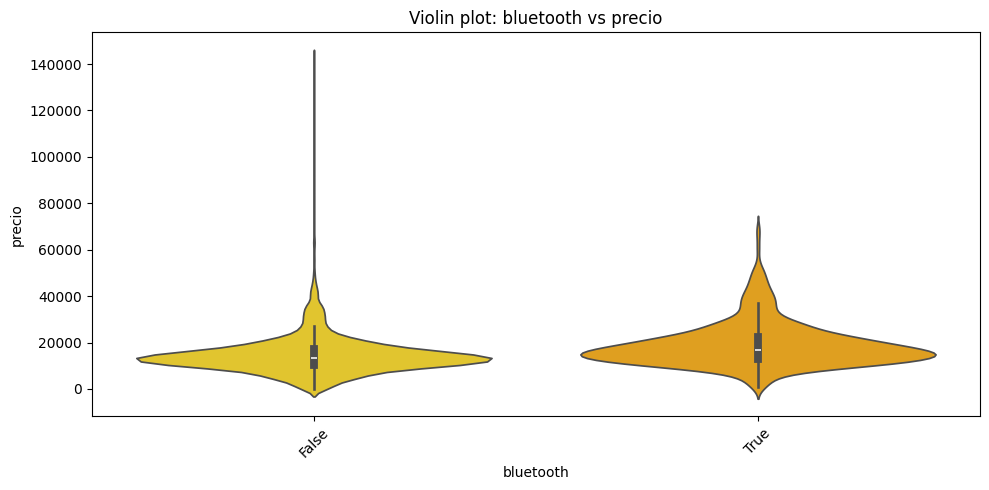

/tmp/ipython-input-3644410205.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


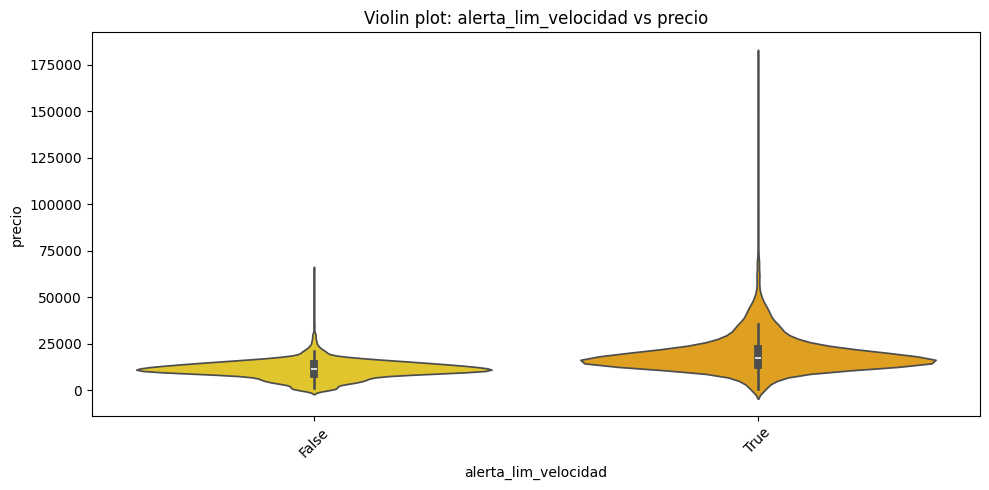

In [53]:
## Kike Variables categoricas con target usando violinplot
## Kike Conclusion: Asientos plegables traseros más caros. Naranja, cuope e Hybrid-petrol más caro
## Kike Seleccionar columnas categóricas (object o category)
cat_cols = df_inicial_test.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure(figsize=(10,5))
    sns.violinplot(
        x=df_inicial_test[col],
        y=df_inicial_test["precio"],
        palette="Wistia"
    )
    plt.title(f"Violin plot: {col} vs precio")
    plt.xlabel(col)
    plt.ylabel("precio")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## PREGUNTA 6

In [2]:
## Kike 6. Transformación de categóricas a numéricas, ¿Qué variables van a transformar? ¿Que técnica se va usar?

In [74]:
## Kike Miramos en un info como están las variables y después hacemos un bucle que me cambie todas las categóricas a numéricas

df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4839 non-null   object        
 8   aire_acondicionado           4357 non-null   object        
 9   camara_trasera               4841 non-null   object        
 10  asientos_traseros_plegables  1452 non-null   object        
 11  elevalunas_electrico         4841 non-null 

In [69]:
## Kike vuelvo a listar todas las variables con sus valores únicos
for i in df_inicial_test:
  print(i,"\n\n",df_inicial_test[i].value_counts(),"\n\n")

modelo 

 modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 76, dtype: int64 


km 

 km
129317.0    2
129214.0    2
193202.0    2
72760.0     2
188713.0    2
           ..
193231.0    1
84058.0     1
303225.0    1
205603.0    1
87542.0     1
Name: count, Length: 4784, dtype: int64 


potencia 

 potencia
135.0    882
120.0    785
85.0     631
100.0    570
105.0    451
        ... 
412.0      1
0.0        1
423.0      1
300.0      1
261.0      1
Name: count, Length: 61, dtype: int64 


fecha_registro 

 fecha_registro
2013-07-01    93
2014-03-01    83
2014-05-01    81
2013-01-01    78
2013-10-01    77
              ..
2004-11-01     1
2009-12-01     1
2005-02-01     1
2004-06-01     1
2005-09-01     1
Name: count, Length: 180, dtype: int

In [75]:
for i in df_inicial_test:
    print(df_inicial_test[i].dtype.kind)

O
f
f
M
O
O
O
O
O
O
O
O
O
O
f
M
M
i


In [66]:
def obtener_lista_variables(dataset):

    lista_numericas=[]
    lista_boolean=[]
    lista_categoricas=[]

    for i in dataset:
        if    (dataset[i].dtype.kind=="f" or dataset[i].dtype.kind=="i") and len(dataset[i].unique())!=2 and (i not in target):
              lista_numericas.append(i)
        elif  (dataset[i].dtype.kind=="f" or dataset[i].dtype.kind=="i") and len(dataset[i].unique())==2 and (i not in target):
              lista_boolean.append(i)
        elif  (dataset[i].dtype.kind=="O") and i not in target:
              lista_categoricas.append(i)

    return lista_numericas, lista_boolean, lista_categoricas

In [67]:
## Kike Paso al dataset las listas
lista_numericas, lista_boolean, lista_categoricas = obtener_lista_variables(df_inicial_test)

In [68]:
print (lista_categoricas)

['modelo', 'tipo_gasolina', 'color', 'tipo_coche', 'volante_regulable', 'aire_acondicionado', 'camara_trasera', 'asientos_traseros_plegables', 'elevalunas_electrico', 'bluetooth', 'alerta_lim_velocidad']


In [ ]:
## Kike Transformamos 11 variables categóricas
## Kike modelo (77), tipo gasolina (6), color (11), tipo coche(9), volante reg(T/F), Aire (T/F), Camara T(T/F), Asientos (T/F), elevalunas (T/F), bluetooth (T/F), Alerta (T/F)

In [71]:
for col in lista_categoricas:
    print(f"Columna: {col}\n")
    print(df_inicial_test[col].value_counts(dropna=False))  # Incluye NaN
    print("\n" + "-"*50 + "\n")


Columna: modelo

modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 77, dtype: int64

--------------------------------------------------

Columna: tipo_gasolina

tipo_gasolina
diesel           4631
petrol            191
hybrid_petrol       8
NaN                 5
Diesel              5
electro             3
Name: count, dtype: int64

--------------------------------------------------

Columna: color

color
black     1499
grey      1070
blue       647
white      484
NaN        445
brown      302
silver     292
red         47
beige       37
green       14
orange       6
Name: count, dtype: int64

--------------------------------------------------

Columna: tipo_coche

tipo_coche
NaN            1460
estate         1107
sedan           821
suv

In [80]:
## Kike Quiero pasar las categoricas a numericas.
## Kike Primero paso las 7 variables T/F. Nos quedan 4 variables categóricas

cols_bool = ["volante_regulable", "aire_acondicionado", "camara_trasera", "asientos_traseros_plegables", "elevalunas_electrico", "bluetooth","alerta_lim_velocidad"]

for col in cols_bool:
    df_inicial_test[col] = np.where(df_inicial_test[col] == "TRUE", 1, 0)


In [82]:
## Kike Creo que no me ha pasado a lista_numericas las 7 variables anteriores
## Kike Se puede hacer un ordinal encoder a tipo_gasolina, color y tipo_coche.
## Kike Pendiente de decidir que se hace con los 77 modelos.

Columna: modelo

modelo
320                  752
520                  633
318                  568
X3                   438
116                  358
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 77, dtype: int64

--------------------------------------------------

Columna: tipo_gasolina

tipo_gasolina
diesel           4631
petrol            191
hybrid_petrol       8
NaN                 5
Diesel              5
electro             3
Name: count, dtype: int64

--------------------------------------------------

Columna: color

color
black     1499
grey      1070
blue       647
white      484
NaN        445
brown      302
silver     292
red         47
beige       37
green       14
orange       6
Name: count, dtype: int64

--------------------------------------------------

Columna: tipo_coche

tipo_coche
NaN            1460
estate         1107
sedan           821
suv

In [81]:
df_inicial_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   modelo                       4840 non-null   object        
 1   km                           4841 non-null   float64       
 2   potencia                     4842 non-null   float64       
 3   fecha_registro               2420 non-null   datetime64[ns]
 4   tipo_gasolina                4838 non-null   object        
 5   color                        4398 non-null   object        
 6   tipo_coche                   3383 non-null   object        
 7   volante_regulable            4843 non-null   int64         
 8   aire_acondicionado           4843 non-null   int64         
 9   camara_trasera               4843 non-null   int64         
 10  asientos_traseros_plegables  4843 non-null   int64         
 11  elevalunas_electrico         4843 non-null 

## PREGUNTA 7

In [3]:
## 7. Escalar variables (usando minmaxscaler) y luego aplicar la correlación final de variables ¿Hay alguna variable finalmente correlacionada?

## PREGUNTA 8

In [ ]:
## 8. Subir un pantallazo con el nombre de TODAS las columnas que tiene el dataframe final final vfin y el tipo de dato que tiene, tip lo más sencillo es hacer un .info al dataframe y tomarle un pantallazo y subirlo, importante deben aparecer TODAS las columnas

In [ ]:
## Es hacer un pantallazo del data frame y del .info y subirlo al enlance.

##PREGUNTA 9

In [ ]:
## 9. Exportar en un excel de las primeras 50 filas del dataset (df.to_excel(...)

In [ ]:
pd.to_excel(df_final,"/content/drive/MyDrive/Colab Notebooks/df_final")

## PREGUNTA 10

In [ ]:
## 10. Sube el programa (el archivo .ipynb, NO EL PICKLE de lo contrario me quedaré sin espacio...) y con esto hemos terminado ;)

In [ ]:
# En archivo voy a descargar .ipynb. Luego lo subo al enlace